In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muhammadumer7804/imf-world-economic-dataset/dataset_2026.csv


# **Step 1 — Load Dataset**

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/muhammadumer7804/imf-world-economic-dataset/dataset_2026.csv', low_memory=False)

print("Shape:", df.shape)
df.head()

Shape: (8200, 79)


,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDICATOR,FREQUENCY,SCALE,UNIT,COUNTRY_UPDATE_DATE,PUBLICATION_DATE,...,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031
0,IMF.RES:WEO(9.0.0),GBR.NGDPD.A,OBS_VALUE,United Kingdom,"Gross domestic product (GDP), Current prices, ...",Annual,Billions,US dollar,9/13/2025,2026-04-14T13:00:00Z,...,3192.851,3422.072,3695.355,4003.022,4264.794,4466.076,4675.048,4898.448,5148.434,5403.155
1,IMF.RES:WEO(9.0.0),GBR.PCPI.A,OBS_VALUE,United Kingdom,"All Items, Consumer price index (CPI), Period ...",Annual,Units,Index,9/13/2025,2026-04-14T13:00:00Z,...,121.665,130.550,133.853,138.368,142.800,146.253,149.178,152.161,155.205,158.309
2,IMF.RES:WEO(9.0.0),ITA.LP.A,OBS_VALUE,Italy,"Population, Persons for countries / Index for ...",Annual,Millions,NaN,9/23/2025,2026-04-14T13:00:00Z,...,59.030,58.997,58.971,58.934,58.879,58.806,58.716,58.611,58.493,58.364
3,IMF.RES:WEO(9.0.0),LIE.LE.A,OBS_VALUE,"Liechtenstein, Principality of","Employed persons, Persons for countries / Inde...",Annual,Millions,NaN,9/29/2025,2026-04-14T13:00:00Z,...,0.043,0.043,0.043,0.044,0.044,0.045,NaN,NaN,NaN,NaN
4,IMF.RES:WEO(9.0.0),GBR.GGXONLB.A,OBS_VALUE,United Kingdom,"Primary net lending (+) / net borrowing (-), G...",Annual,Billions,Domestic currency,9/13/2025,2026-04-14T13:00:00Z,...,-26.845,-101.457,-116.298,-83.997,-38.632,-12.753,8.109,36.219,48.305,50.306


# **Step 2 — Column Names Check**

In [5]:
print(df.columns[:27].tolist())

['DATASET', 'SERIES_CODE', 'OBS_MEASURE', 'COUNTRY', 'INDICATOR', 'FREQUENCY', 'SCALE', 'UNIT', 'COUNTRY_UPDATE_DATE', 'PUBLICATION_DATE', 'UPDATE_DATE', 'METHODOLOGY', 'METHODOLOGY_NOTES', 'LATEST_ACTUAL_ANNUAL_DATA', 'HISTORICAL_DATA_SOURCE', 'BASE_YEAR', 'START_END_MONTHS_OF_REPORTING_YEAR', 'CHAIN_WEIGHTED', 'BASIS_OF_PROJECTIONS', 'VALUATION', 'PRICES_SECTOR_HARMONIZED_PRICES', 'LABOR_SECTOR_EMPLOYMENT_TYPE', 'FISCAL_SECTOR_GENERAL_GOVERNMENT_COMPOSITION', 'FISCAL_SECTOR_VALUATION_OF_DEBT', 'FISCAL_SECTOR_INSTRUMENTS_INCLUDED_IN_GROSS_AND_NET_DEBT', 'TRADE_SECTOR_OIL_COVERAGE', 'PRIMARY_DOMESTIC_CURRENCY']


# **Step 3 — Select Only Useful Columns**

In [6]:
year_columns = [str(year) for year in range(1980, 2032)]
useful_columns = ['COUNTRY', 'INDICATOR', 'UNIT'] + year_columns

df_clean = df[useful_columns].copy()

print(df_clean.shape)
df_clean.head()

(8200, 55)


,COUNTRY,INDICATOR,UNIT,1980,1981,1982,1983,1984,1985,1986,...,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031
0,United Kingdom,"Gross domestic product (GDP), Current prices, ...",US dollar,604.664,589.092,560.122,533.763,505.859,538.269,656.445,...,3192.851,3422.072,3695.355,4003.022,4264.794,4466.076,4675.048,4898.448,5148.434,5403.155
1,United Kingdom,"All Items, Consumer price index (CPI), Period ...",Index,31.268,35.079,38.064,40.043,41.824,43.982,45.577,...,121.665,130.550,133.853,138.368,142.800,146.253,149.178,152.161,155.205,158.309
2,Italy,"Population, Persons for countries / Index for ...",NaN,56.388,56.479,56.524,56.563,56.565,56.588,56.598,...,59.030,58.997,58.971,58.934,58.879,58.806,58.716,58.611,58.493,58.364
3,"Liechtenstein, Principality of","Employed persons, Persons for countries / Inde...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.043,0.043,0.043,0.044,0.044,0.045,NaN,NaN,NaN,NaN
4,United Kingdom,"Primary net lending (+) / net borrowing (-), G...",Domestic currency,-1.735,-5.118,-1.751,-2.646,-1.942,-0.534,0.153,...,-26.845,-101.457,-116.298,-83.997,-38.632,-12.753,8.109,36.219,48.305,50.306


# **Step 4 — Convert Wide Format to Long Format (Melt)**

In [7]:
df_long = df_clean.melt(
    id_vars=['COUNTRY', 'INDICATOR', 'UNIT'],
    value_vars=year_columns,
    var_name='Year',
    value_name='Value'
)

df_long['Year'] = df_long['Year'].astype(int)

print(df_long.shape)
df_long.head(10)

(426400, 5)


,COUNTRY,INDICATOR,UNIT,Year,Value
0,United Kingdom,"Gross domestic product (GDP), Current prices, ...",US dollar,1980,604.664
1,United Kingdom,"All Items, Consumer price index (CPI), Period ...",Index,1980,31.268
2,Italy,"Population, Persons for countries / Index for ...",NaN,1980,56.388
3,"Liechtenstein, Principality of","Employed persons, Persons for countries / Inde...",NaN,1980,NaN
4,United Kingdom,"Primary net lending (+) / net borrowing (-), G...",Domestic currency,1980,-1.735
5,Malta,"Employed persons, Persons for countries / Inde...",NaN,1980,NaN
6,United States,"Revenue, General government, Percent of GDP",Percent,1980,NaN
7,United States,"Gross domestic product (GDP), Price deflator, ...",Index,1980,39.372
8,Latin America and the Caribbean (LAC),"Gross capital formation, Percent of GDP",Percent,1980,23.739
9,Honduras,"Gross domestic product (GDP), Current prices, ...",Domestic currency,1980,2149.934


# **Step 5 — Check Missing Values**

In [8]:
print(df_long.isnull().sum())
print()
print("Missing % in Value column:", (df_long['Value'].isnull().sum() / len(df_long)) * 100)

COUNTRY          0
INDICATOR        0
UNIT         61568
Year             0
Value        64667
dtype: int64

Missing % in Value column: 15.16580675422139


# **Step 6 — List All Available Indicators**

In [9]:
indicators_list = df_long['INDICATOR'].unique()
print(len(indicators_list))
for ind in indicators_list:
    print(ind)

145
Gross domestic product (GDP), Current prices, US dollar
All Items, Consumer price index (CPI), Period average
Population, Persons for countries / Index for country groups
Employed persons, Persons for countries / Index for country groups
Primary net lending (+) / net borrowing (-), General government, Domestic currency
Revenue, General government, Percent of GDP
Gross domestic product (GDP), Price deflator, Index
Gross capital formation, Percent of GDP
Gross domestic product (GDP), Current prices, Per capita, Domestic currency
Gross domestic product (GDP), Current prices, Domestic currency
Gross national savings, Percent of GDP
All Items, Consumer price index (CPI), Period average, percent change
Other investment, Net (assets minus liabilities), US dollar
Gross domestic product (GDP), Constant prices, Percent change
Unemployment rate
Expenditure, General government, Percent of GDP
Net lending (+) / net borrowing (-), General government, Percent of GDP
Gross domestic product (GDP), 

# **Step 7 — Filter to Core Indicators**

In [10]:
core_indicators = [
    'Gross domestic product (GDP), Current prices, US dollar',
    'Gross domestic product (GDP), Constant prices, Percent change',
    'Unemployment rate',
    'Population, Persons for countries / Index for country groups',
    'All Items, Consumer price index (CPI), Period average, percent change',
    'Net lending (+) / net borrowing (-), General government, Percent of GDP',
    'External debt, Percent of GDP',
    'Current account balance (credit less debit), Percent of GDP'
]

df_core = df_long[df_long['INDICATOR'].isin(core_indicators)].copy()

print(df_core.shape)
print(df_core['INDICATOR'].unique())

(71344, 5)
['Gross domestic product (GDP), Current prices, US dollar'
 'Population, Persons for countries / Index for country groups'
 'All Items, Consumer price index (CPI), Period average, percent change'
 'Gross domestic product (GDP), Constant prices, Percent change'
 'Unemployment rate'
 'Net lending (+) / net borrowing (-), General government, Percent of GDP'
 'Current account balance (credit less debit), Percent of GDP'
 'External debt, Percent of GDP']


# **Step 8 — Check Missing Values in Filtered Data**

In [11]:
print(df_core.isnull().sum())
print()
print("Missing % in Value:", (df_core['Value'].isnull().sum() / len(df_core)) * 100)

COUNTRY          0
INDICATOR        0
UNIT         16588
Year             0
Value         9019
dtype: int64

Missing % in Value: 12.641567616057412


# **Step 9 — Check for Regional Aggregates vs Actual Countries**

In [12]:
all_entities = df_core['COUNTRY'].unique()
print(len(all_entities))
print(sorted(all_entities))

210
['ASEAN-5', 'Advanced Economies', 'Afghanistan, Islamic Republic of', 'Albania', 'Algeria', 'Andorra, Principality of', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia, Republic of', 'Aruba, Kingdom of the Netherlands', 'Australia', 'Austria', 'Azerbaijan, Republic of', 'Bahamas, The', 'Bahrain, Kingdom of', 'Bangladesh', 'Barbados', 'Belarus, Republic of', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', "China, People's Republic of", 'Colombia', 'Comoros, Union of the', 'Congo, Democratic Republic of the', 'Congo, Republic of', 'Costa Rica', 'Croatia, Republic of', 'Cyprus', 'Czech Republic', "Côte d'Ivoire", 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt, Arab Republic of', 'El Salvador', 'Emerging Market and Developing Economies', 'Emerging and

# **Step 10 — Separate Countries from Regional Groups**

In [13]:
group_entities = [
    'ASEAN-5', 'Advanced Economies', 'Emerging Market and Developing Economies',
    'Emerging and Developing Asia', 'Emerging and Developing Europe', 'Euro Area (EA)',
    'European Union (EU)', 'G7', 'Latin America and the Caribbean (LAC)',
    'Middle East and Central Asia', 
    'Other Advanced Economies (Advanced Economies excluding G7 and Euro Area countries)',
    'Sub-Saharan Africa (SSA)', 'World'
]

df_countries = df_core[~df_core['COUNTRY'].isin(group_entities)].copy()
df_groups = df_core[df_core['COUNTRY'].isin(group_entities)].copy()

print("Countries data:", df_countries.shape)
print("Groups data:", df_groups.shape)
print("Unique countries:", df_countries['COUNTRY'].nunique())

Countries data: (67548, 5)
Groups data: (3796, 5)
Unique countries: 197


# **Step 11 — Business/Economic KPI Overview (Latest Year Snapshot)**

In [14]:
latest_year = 2025

gdp_2025 = df_countries[
    (df_countries['INDICATOR'] == 'Gross domestic product (GDP), Current prices, US dollar') &
    (df_countries['Year'] == latest_year)
].sort_values('Value', ascending=False)

print("Top 10 Economies by GDP (2025, US$ Billions):")
print(gdp_2025[['COUNTRY', 'Value']].head(10))

Top 10 Economies by GDP (2025, US$ Billions):
                            COUNTRY      Value
369223                United States  30767.075
376363  China, People's Republic of  19626.247
369279                      Germany   5048.059
369954                        Japan   4435.163
369000               United Kingdom   4003.022
373066                        India   3916.312
369516                       France   3368.925
376177           Russian Federation   2587.938
369411                        Italy   2550.111
369868                       Canada   2319.900


# **Step 12 — Visualize Top 10 Economies**

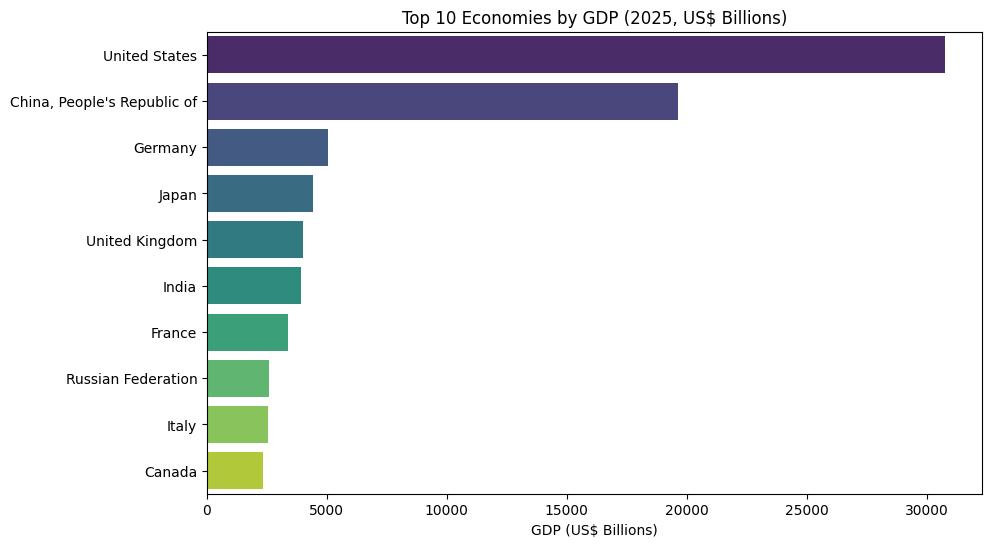

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=gdp_2025.head(10), x='Value', y='COUNTRY', hue='COUNTRY', palette='viridis', legend=False)
plt.title('Top 10 Economies by GDP (2025, US$ Billions)')
plt.xlabel('GDP (US$ Billions)')
plt.ylabel('')
plt.show()

# **Step 13 — GDP Growth Rate Comparison (Who's Growing Fastest?)**

In [16]:
growth_2025 = df_countries[
    (df_countries['INDICATOR'] == 'Gross domestic product (GDP), Constant prices, Percent change') &
    (df_countries['Year'] == 2025)
].sort_values('Value', ascending=False)

print("Top 10 Fastest Growing Economies (2025):")
print(growth_2025[['COUNTRY', 'Value']].head(10))

print()
print("Bottom 10 (Slowest/Shrinking Economies, 2025):")
print(growth_2025[['COUNTRY', 'Value']].tail(10))

Top 10 Fastest Growing Economies (2025):
                                             COUNTRY   Value
375263                      South Sudan, Republic of  46.094
371458                                        Guyana  19.309
374588                                         Libya  15.871
370092                                       Ireland  12.338
376048                               Kyrgyz Republic  11.096
374196  Ethiopia, The Federal Democratic Republic of   9.151
372956                      Taiwan Province of China   8.676
376194                       Tajikistan, Republic of   8.400
373587                                       Vietnam   8.019
375109                                       Senegal   7.881

Bottom 10 (Slowest/Shrinking Economies, 2025):
                               COUNTRY  Value
370637                         Bolivia -1.200
372017       Iran, Islamic Republic of -1.525
372772                         Myanmar -1.964
371026                           Haiti -2.713
373911  Eq

# **Step 14 — Visualize: Fastest vs Slowest Growth**

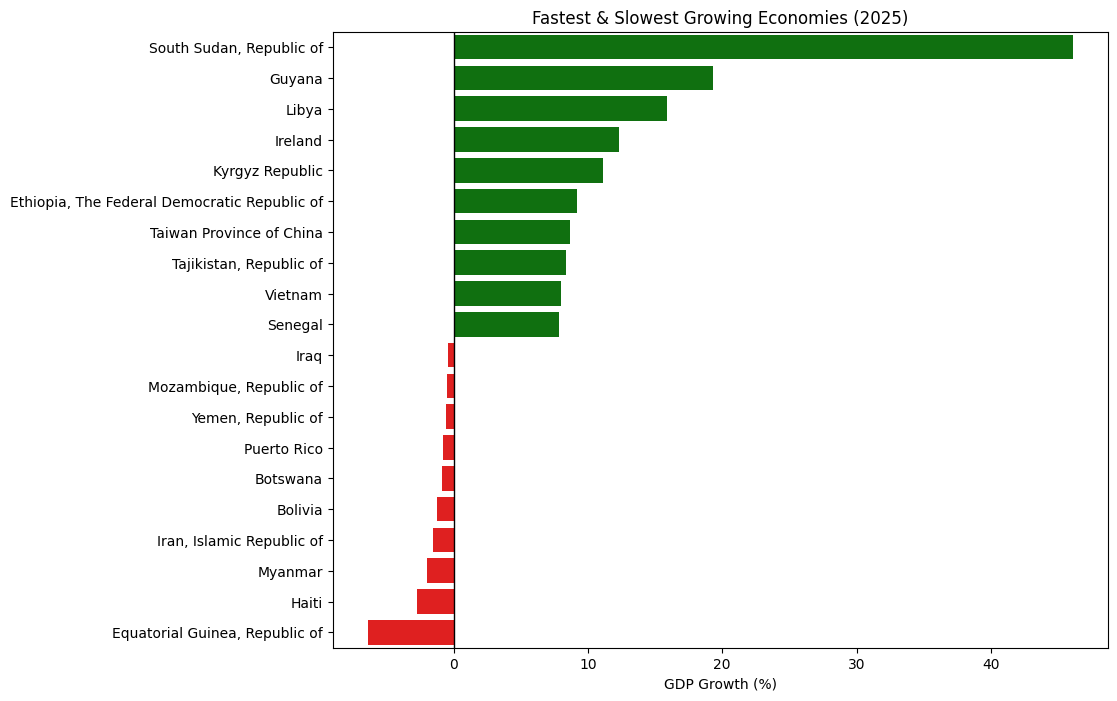

In [17]:
top_bottom = pd.concat([growth_2025.head(10), growth_2025.dropna().tail(10)])

plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in top_bottom['Value']]
sns.barplot(data=top_bottom, x='Value', y='COUNTRY', hue='COUNTRY', palette=colors, legend=False)
plt.title('Fastest & Slowest Growing Economies (2025)')
plt.xlabel('GDP Growth (%)')
plt.axvline(0, color='black', linewidth=1)
plt.ylabel('')
plt.show()

# **Step 15 — Inflation Analysis (Who's Struggling with Inflation?)**

In [18]:
inflation_2025 = df_countries[
    (df_countries['INDICATOR'] == 'All Items, Consumer price index (CPI), Period average, percent change') &
    (df_countries['Year'] == 2025)
].sort_values('Value', ascending=False)

print("Top 10 Highest Inflation (2025):")
print(inflation_2025[['COUNTRY', 'Value']].head(10))

print()
print("Top 10 Lowest Inflation / Deflation (2025):")
print(inflation_2025[['COUNTRY', 'Value']].tail(10))

Top 10 Highest Inflation (2025):
                                    COUNTRY    Value
371426  Venezuela, República Bolivariana de  251.954
375260                                Sudan  100.222
375067             South Sudan, Republic of   97.616
374952                             Zimbabwe   81.438
372045            Iran, Islamic Republic of   50.861
370650                            Argentina   41.920
370177                 Türkiye, Republic of   34.883
373622                              Burundi   34.196
374605                               Malawi   28.381
370837                                Haiti   28.306

Top 10 Lowest Inflation / Deflation (2025):
                      COUNTRY  Value
372014    Bahrain, Kingdom of -0.138
372626      Brunei Darussalam -0.303
373374               Djibouti -0.317
375476           Burkina Faso -0.550
375405      Fiji, Republic of -1.400
373928                   Chad -2.574
374819                  Niger -4.561
372443   Syrian Arab Republic    NaN
372942

# **Step 16 — Visualize Top Inflation Countries**

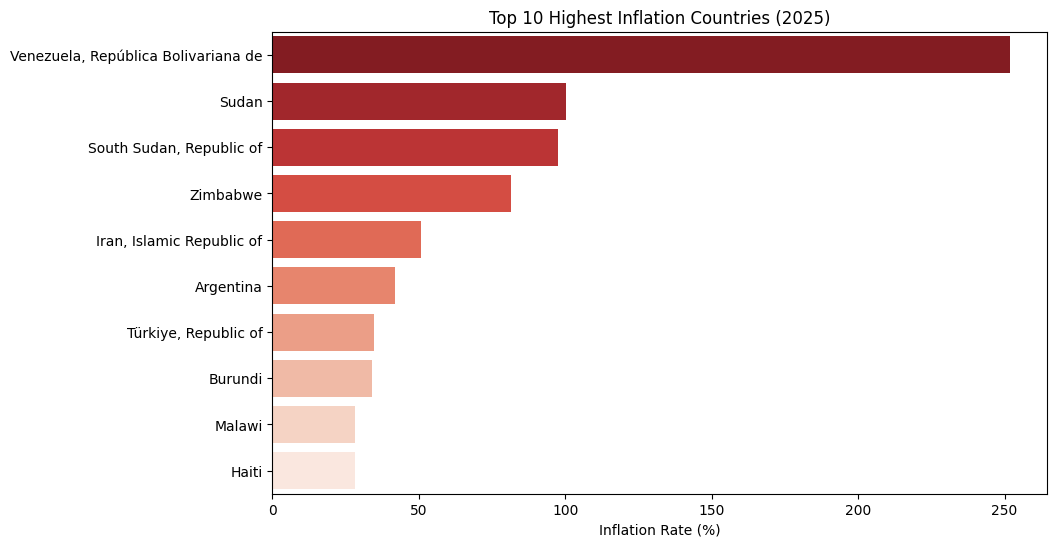

In [19]:
plt.figure(figsize=(10, 6))
top_inflation = inflation_2025.head(10)
sns.barplot(data=top_inflation, x='Value', y='COUNTRY', hue='COUNTRY', palette='Reds_r', legend=False)
plt.title('Top 10 Highest Inflation Countries (2025)')
plt.xlabel('Inflation Rate (%)')
plt.ylabel('')
plt.show()

# **Step 17 — Historical Trend: Global Average Inflation Over Time**

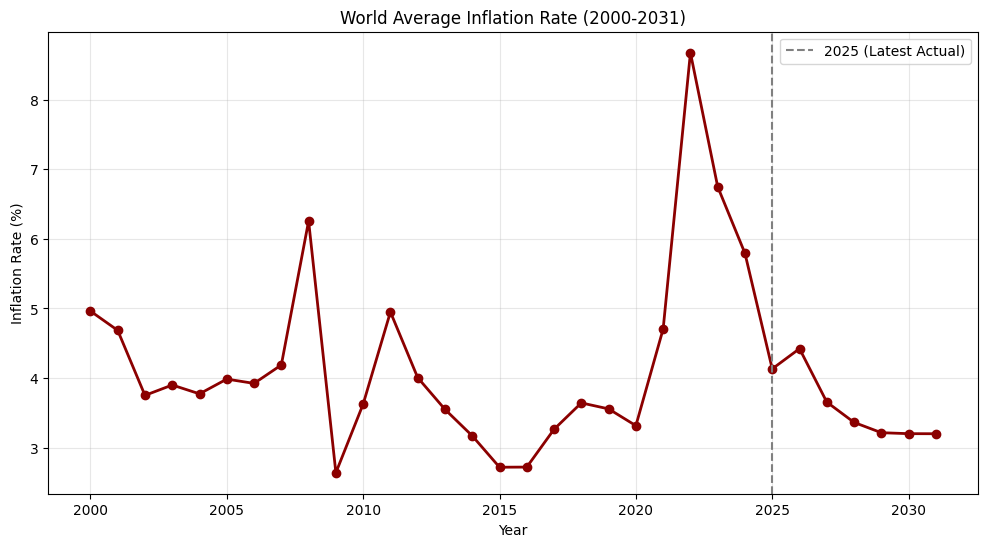

In [20]:
world_inflation = df_groups[
    (df_groups['COUNTRY'] == 'World') &
    (df_groups['INDICATOR'] == 'All Items, Consumer price index (CPI), Period average, percent change') &
    (df_groups['Year'] >= 2000)
]

plt.figure(figsize=(12, 6))
plt.plot(world_inflation['Year'], world_inflation['Value'], marker='o', linewidth=2, color='darkred')
plt.title('World Average Inflation Rate (2000-2031)')
plt.xlabel('Year')
plt.ylabel('Inflation Rate (%)')
plt.axvline(2025, color='gray', linestyle='--', label='2025 (Latest Actual)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **Step 18 — Unemployment Trend Over Time (Global)**

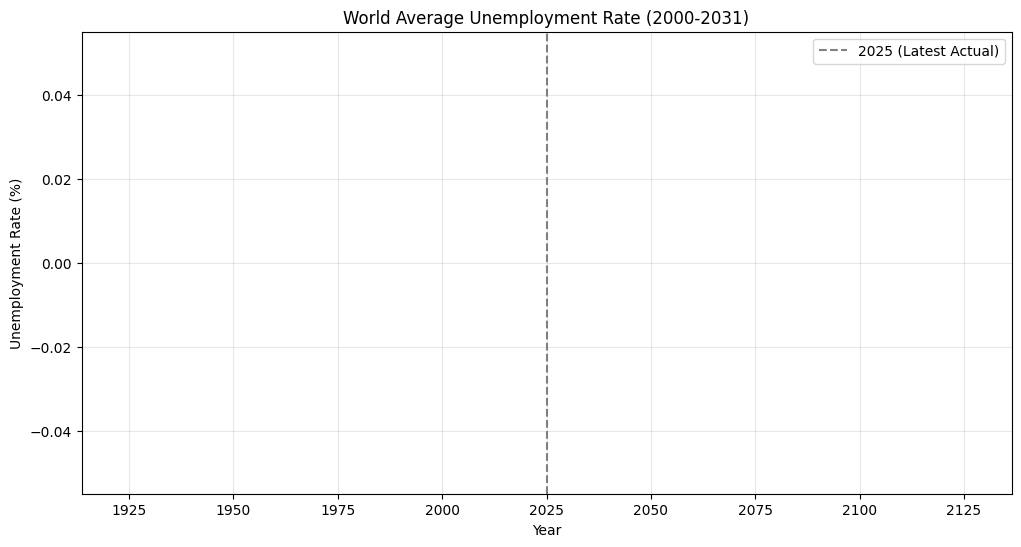

In [21]:
world_unemployment = df_groups[
    (df_groups['COUNTRY'] == 'World') &
    (df_groups['INDICATOR'] == 'Unemployment rate') &
    (df_groups['Year'] >= 2000)
]

plt.figure(figsize=(12, 6))
plt.plot(world_unemployment['Year'], world_unemployment['Value'], marker='o', linewidth=2, color='darkblue')
plt.title('World Average Unemployment Rate (2000-2031)')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')
plt.axvline(2025, color='gray', linestyle='--', label='2025 (Latest Actual)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **Step 18 (Revised) — Unemployment Trend (Average Across Countries)**